In [2]:
import sys,os
from dataclasses import dataclass
from pathlib import Path
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, repo_root)
os.environ["CMB_ML_DATA"] = "/bigdata/cmb_project/data/"
sys.path.append("/bigdata/aankit/lost_in_space/")
os.environ['XDG_CONFIG_HOME'] = '/bigdata/cmb_project/xdg_home/xdg_config'
os.environ['XDG_CACHE_HOME'] = '/bigdata/cmb_project/xdg_home/xdg_cache'
from cmbml.utils.planck_instrument import make_instrument_manual

In [3]:
import healpy as hp
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from typing import List
%matplotlib inline 

### Useful funcs

In [19]:
@dataclass
class Record:
    name: str
    label: str
    sky: np.ndarray
    cl: np.ndarray
    color: str
    def __str__(self) -> str:
        return f"{self.name}: {self.label}, color: {self.color}"
    def __repr__(self) -> str:
        return self.__str__()


class Records:
    prop_cycle = plt.rcParams['axes.prop_cycle']
    mpl_colors = prop_cycle.by_key()['color']
    del prop_cycle  # clean up namespace
    def __init__(self):
        self.r = {}
    def get(self, id):
        if isinstance(id, str):
            return self.get_by_name(id)
        elif isinstance(id, int):
            return self.get_by_idx(id)
        else:
            raise ValueError(f"Invalid id {id}")
    def get_by_name(self, name):
        return self.r[name]
    def get_by_idx(self, idx):
        return list(self.r.values())[idx]
    def add(self, name, label, sky, dl):
        if name in self.r:
            new_color = self.get(name).color
        else:
            #fixed limited color issue
            color_index = len(self.r) % len(self.mpl_colors)
            new_color = self.mpl_colors[color_index]
        self.r[name] = Record(name, label, sky, dl, new_color)
    def add_record(self, record):
        record = Record(record.name, record.label, record.sky, record.dl, self.mpl_colors[len(self.r)])
        self.r[record.name] = record
    def get_labels(self, ids):
        return [self.get(id).label for id in ids]
    def get_colors(self, ids):
        return [self.get(id).color for id in ids]
    def get_skys(self, ids):
        return [self.get(id).sky for id in ids]
    def get_cls(self, ids):
        return [self.get(id).cl for id in ids]
    def get_many(self, ids):
        return [self.get(id) for id in ids]
    def get_all(self):
        return list(self.r.values())
    def __str__(self) -> str:
        if len(self.r) == 0:
            return "No records."
        for r in self.r.values():
            return "\n".join([str(r) for r in self.r.values()])
    def __repr__(self) -> str:
        return self.__str__()
    def __iter__(self):
        return iter(self.r.values())

def plot_ps(many_ps_list,
            labels, 
            # signal_type=None, 
            title=None, 
            x_low=None,
            x_high=None,
            y_low=None,
            y_high=None,
            colors=None,
            has_theory=False,
            loglog=True,
            scatter=True,
            helper_funcs=None):
    if not isinstance(many_ps_list, list):
        many_ps_list = [many_ps_list]
    if not isinstance(labels, list):
        labels = [labels]
    if not isinstance(colors, list):
        colors = [colors]
    # Set up for Noise specifically:
    y_label="$N_{\\ell}(\\mu K^2)$"
    x_label="$\\ell$"
    plt.figure()
    for i, (ps, label) in enumerate(zip(many_ps_list, labels)):
        if i == 0 and has_theory:  # Ideally, we could get a functional form for the noise. We've put a pin in this.
            style = '--'
            alpha = 1
        else:
            style = '-'
            alpha = 0.6
        color = colors[i] if colors is not None else None
        if scatter:
            ells = np.arange(len(ps))
            plt.scatter(x = ells, 
                        y = ps,
                        s=1,
                        label=label, 
                        color=color, 
                        alpha=alpha)
        else:
            plt.plot(ps, style, label=label, color=color, alpha=alpha)
    if isinstance(helper_funcs, list):
        for helper in helper_funcs:
            helper(plt)
    elif helper_funcs is not None:
        helper_funcs(plt)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    if loglog:
        plt.xscale('log')
        plt.yscale('log')
        if x_low is None:
            x_low = 1
        if y_low is None:
            y_low = 1
        plt.xlim([x_low, x_high])
        plt.ylim([y_low, y_high])
    else:
        plt.xlim([0, x_high])
        plt.ylim([0, y_high])
    plt.legend()
    plt.title(title)
    plt.show()

def make_histograms(records: Records, record_names_to_use: List[str], n_bins=100, force_lims=None):
    oal_min = None
    oal_max = None
    if force_lims is not None:
        oal_min, oal_max = force_lims
    else:
        for use_this in record_names_to_use:
            this_sky = records.get(use_this).sky
            this_min = this_sky.min()
            this_max = this_sky.max()
            oal_min = this_min if oal_min is None else min(oal_min, this_min)
            oal_max = this_max if oal_max is None else max(oal_max, this_max)
    bins = np.linspace(oal_min, oal_max, n_bins)

    plt.figure(figsize=(10, 6))
    for use_this in record_names_to_use:
        rec = records.get(use_this)
        # plt.hist(rec.sky, bins=bins, alpha=0.2, label=rec.label, color=rec.color)
        # plt.hist(rec.sky, bins=bins, alpha=0.2, label=rec.label, color=rec.color, edgecolor=rec.color)
        plt.hist(rec.sky, bins=bins, label=rec.label, color=rec.color, histtype='step')
    plt.legend()
    plt.title("Histogram of Noise Maps by Pixel Count")
    plt.show()

def get_units(fn):
    with fits.open(fn) as hdul:
        units = hdul[1].header["TUNIT1"]
    return units

## Create noise instrument

In [ ]:
deltabandpass_path = "/bigdata/aankit/CMB_data/Assets/CMB-ML/cmb-ml_deltabandpass.tbl"
lfi_path = "/bigdata/aankit/rimo_files/LFI_RIMO_R3.31.fits"
hfi_path = "/bigdata/aankit/rimo_files/HFI_RIMO_R3.00.fits"

nom_freqs = [30, 44, 70, 100, 143, 217, 353, 545, 857]

# create Instrument object from the new manual function
print("Creating Instrument object...")
instrument = make_instrument_manual(
    nom_freqs=nom_freqs,
    deltabandpass_path=deltabandpass_path,
    lfi_path=lfi_path,
    hfi_path=hfi_path,
    scen_fields=None,       # Defaults to 'I' (Intensity/Temperature) only
    use_rimo=True,          # Default
    # use_rimo_cen_freq=True, # Default
    # trim_to_mass=0.999      # Default
)
# --- Inspect Instrument Object ---
'''attributes = [a for a in dir(instrument) if not a.startswith('_')]
print(attributes)
'''
print(f"Instrument created!")

Creating Instrument object...
Instrument created!


## Load correlated noise

### Check units

In [21]:
NOISE_BASE_DIR = Path("/bigdata/cmb_project/data/Assets/PlanckNoise/")
MC_REALIZATION = 83 
mc_str = f"{MC_REALIZATION:05d}"
noise_maps = {}
recs = Records()

In [22]:
def get_units(filepath):
    with fits.open(filepath) as hdul:
        units = hdul[1].header.get('TUNIT1', 'Unknown')
    return units

for freq in instrument.dets:
    # print(f"  - /Frequency {freq} GHz")
    freq_str = f"{freq:03d}"
    filename = f"ffp10_noise_{freq_str}_full_map_mc_{mc_str}.fits"
    full_path = NOISE_BASE_DIR / filename
    input_unit = get_units(full_path)
    print(f"Frequency {freq} GHz has input unit: {input_unit}")

Frequency 30 GHz has input unit: K_CMB
Frequency 44 GHz has input unit: K_CMB
Frequency 70 GHz has input unit: K_CMB
Frequency 100 GHz has input unit: K_CMB
Frequency 143 GHz has input unit: K_CMB
Frequency 217 GHz has input unit: K_CMB
Frequency 353 GHz has input unit: K_CMB
Frequency 545 GHz has input unit: MJy/sr
Frequency 857 GHz has input unit: MJy/sr


In [23]:
print(f"Loading FFP10 Correlated Noise Maps (MC {MC_REALIZATION})...")

for freq in instrument.dets:
    # print(f"  - /Frequency {freq} GHz")
    freq_str = f"{freq:03d}"
    filename = f"ffp10_noise_{freq_str}_full_map_mc_{mc_str}.fits"
    full_path = NOISE_BASE_DIR / filename
    input_unit = get_units(full_path)
    target_unit = "UK_CMB"
    conversion_factor = 1.0
    if input_unit in ["K", "K_CMB"]:
        conversion_factor = 1e6  # Multiply by 10^6 to get uK_CMB
        print(f"[{freq} GHz] Input unit is {input_unit}. Applying factor 1e6.")
    elif input_unit == target_unit:
        print(f"[{freq} GHz] Input unit is already {target_unit}. No conversion needed.")
    else:
        # Handle cases like MJy/sr
        print(f"[{freq} GHz] WARNING: Unknown unit {input_unit}. Assuming K_CMB and converting.")
        conversion_factor = 1e6

    noise_map = hp.read_map(str(full_path), field=0, verbose=False)
    noise_maps[freq] = noise_map

    noise_map_uK = noise_map * conversion_factor

    lmax = hp.get_nside(noise_map_uK) * 3 - 1
    nl_spectrum = hp.anafast(noise_map_uK, lmax=lmax, iter=0, pol=False)

    name = f"ffp10_noise_{freq}GHz"
    label = f"{freq} GHz"

    recs.add(name, label, noise_map_uK, nl_spectrum)
    print(f"Processed and stored {freq} GHz noise in {target_unit}.")
print('\nCorrelated noise loading complete.')

Loading FFP10 Correlated Noise Maps (MC 83)...
[30 GHz] Input unit is K_CMB. Applying factor 1e6.


/tmp/ipykernel_2269911/2515717926.py:21: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  noise_map = hp.read_map(str(full_path), field=0, verbose=False)


Processed and stored 30 GHz noise in UK_CMB.
[44 GHz] Input unit is K_CMB. Applying factor 1e6.
Processed and stored 44 GHz noise in UK_CMB.
[70 GHz] Input unit is K_CMB. Applying factor 1e6.
Processed and stored 70 GHz noise in UK_CMB.
[100 GHz] Input unit is K_CMB. Applying factor 1e6.
Processed and stored 100 GHz noise in UK_CMB.
[143 GHz] Input unit is K_CMB. Applying factor 1e6.
Processed and stored 143 GHz noise in UK_CMB.
[217 GHz] Input unit is K_CMB. Applying factor 1e6.
Processed and stored 217 GHz noise in UK_CMB.
[353 GHz] Input unit is K_CMB. Applying factor 1e6.
Processed and stored 353 GHz noise in UK_CMB.
[545 GHz] WARNING: Unknown unit MJy/sr. Assuming K_CMB and converting.
Processed and stored 545 GHz noise in UK_CMB.
[857 GHz] WARNING: Unknown unit MJy/sr. Assuming K_CMB and converting.
Processed and stored 857 GHz noise in UK_CMB.

Correlated noise loading complete.


/tmp/ipykernel_2269911/45955174.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


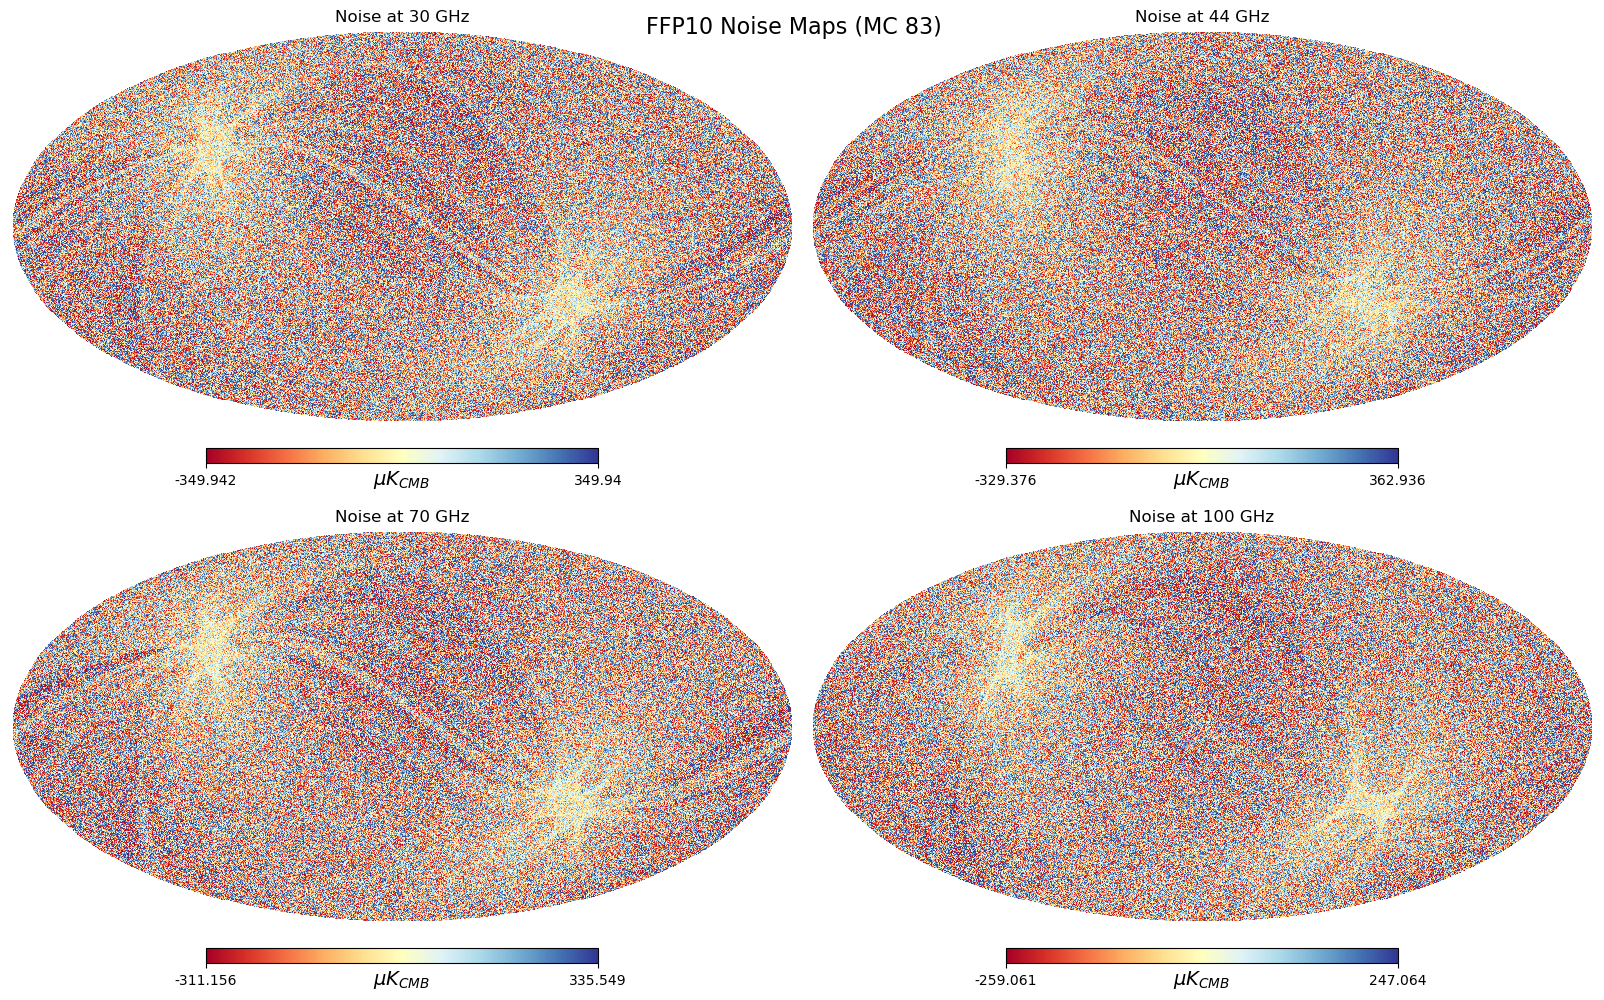

In [24]:
plot_freqs = [30, 44, 70, 100, 143, 217, 353]

# Set up the plot environment (4 plots in a 2x2 grid)
fig = plt.figure(figsize=(16, 10))
# Ensure MC_REALIZATION is defined from your previous cell (e.g., 83)
plt.suptitle(f"FFP10 Noise Maps (MC {MC_REALIZATION})", fontsize=16) 

# --- Plotting Loop (FIXED) ---
for i, freq in enumerate(plot_freqs):
    
    if i<4:
        record_name = f"ffp10_noise_{freq}GHz"
        r = recs.get(record_name)
        noise_map_uK = r.sky
            
        hp.mollview(
            noise_map_uK, 
            title=f"Noise at {freq} GHz", 
            unit=r"$\mu K_{CMB}$", # This unit is now correct for the data
            # coord=['E'], 
            cmap='RdYlBu', 
            sub=(2, 2, i + 1), 
            cbar=True,
            norm='hist'
    )

# Adjust layout and display the figure
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Calculate Power spectrum

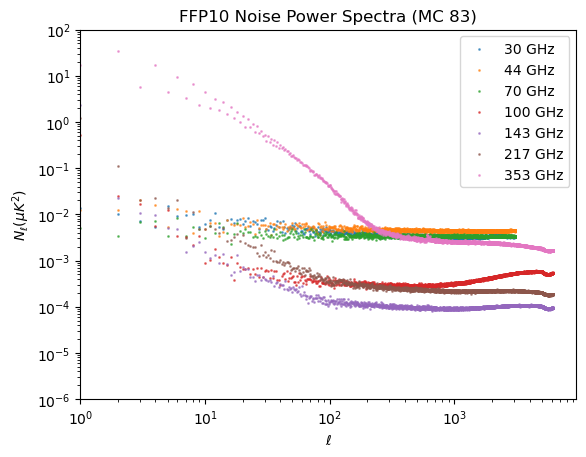

In [25]:
ps_list = []
labels = []
colors = []
for freq in plot_freqs:
    record_name = f"ffp10_noise_{freq}GHz"
    r = recs.get(record_name)
    ps_list.append(r.cl)
    labels.append(r.label)
    colors.append(r.color)

plot_ps(ps_list,
        labels,
        title=f"FFP10 Noise Power Spectra (MC {MC_REALIZATION})",
        # x_low=1,
        # x_high=3000,
        y_low=1e-6,
        y_high=1e2,
        colors=colors,
        has_theory=False,
        loglog=True,
        scatter=True)


## Combine signal and noise

In [26]:
SIGNAL_BASE_DIR = Path("/bigdata/cmb_project/data/Datasets/I_512_1550/Simulation/Test/sim0000/")
MAP_UNIT = r"$\mu K_{CMB}$"

In [27]:
signal_data = {}
for freq in instrument.dets:
    filename = f"obs_{freq}_map.fits"
    full_path = SIGNAL_BASE_DIR / filename 
    input_unit = get_units(full_path)
    conversion_factor = 1e6 if input_unit in ["K", "K_CMB"] else 1.0

    signal_map_raw = hp.read_map(str(full_path), field=0, verbose=False)
    signal_map_uK = signal_map_raw * conversion_factor

    lmax = hp.get_nside(signal_map_uK) * 3 - 1
    cl_spectrum_signal = hp.anafast(signal_map_uK, lmax=lmax, iter=0, pol=False)

    signal_data[freq] = signal_map_uK

    name = f"signal_{freq}GHz"
    label = f"Signal Only, {freq} GHz"
    recs.add(name, label, signal_map_uK, cl_spectrum_signal)

    print(f"Processed and stored singal map for {freq} GHz")

print("signal processing complete!")

/tmp/ipykernel_2269911/1781496625.py:8: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  signal_map_raw = hp.read_map(str(full_path), field=0, verbose=False)


Processed and stored singal map for 30 GHz
Processed and stored singal map for 44 GHz
Processed and stored singal map for 70 GHz
Processed and stored singal map for 100 GHz
Processed and stored singal map for 143 GHz
Processed and stored singal map for 217 GHz
Processed and stored singal map for 353 GHz
Processed and stored singal map for 545 GHz
Processed and stored singal map for 857 GHz
signal processing complete!


In [ ]:
attributes = [a for a in dir(recs) if not a.startswith('_')]
print(attributes)
print(recs.get_by_name)

['add', 'add_record', 'get', 'get_all', 'get_by_idx', 'get_by_name', 'get_cls', 'get_colors', 'get_labels', 'get_many', 'get_skys', 'mpl_colors', 'r']
<bound method Records.get_by_name of ffp10_noise_30GHz: 30 GHz, color: #1f77b4
ffp10_noise_44GHz: 44 GHz, color: #ff7f0e
ffp10_noise_70GHz: 70 GHz, color: #2ca02c
ffp10_noise_100GHz: 100 GHz, color: #d62728
ffp10_noise_143GHz: 143 GHz, color: #9467bd
ffp10_noise_217GHz: 217 GHz, color: #8c564b
ffp10_noise_353GHz: 353 GHz, color: #e377c2
ffp10_noise_545GHz: 545 GHz, color: #7f7f7f
ffp10_noise_857GHz: 857 GHz, color: #bcbd22
signal_30GHz: Signal Only, 30 GHz, color: #17becf
signal_44GHz: Signal Only, 44 GHz, color: #1f77b4
signal_70GHz: Signal Only, 70 GHz, color: #ff7f0e
signal_100GHz: Signal Only, 100 GHz, color: #2ca02c
signal_143GHz: Signal Only, 143 GHz, color: #d62728
signal_217GHz: Signal Only, 217 GHz, color: #9467bd
signal_353GHz: Signal Only, 353 GHz, color: #8c564b
signal_545GHz: Signal Only, 545 GHz, color: #e377c2
signal_857GH

In [38]:
observed_maps = {}
print("Combining signal and noise...")
noise_record_names = [name for name in recs.r.keys() if name.startswith("ffp10_noise_")]
for name in noise_record_names:
    r_noise = recs.get(name)
    freq = int(r_noise.name.split('GHz')[0].split('_')[-1])
    lmax = 3 * hp.get_nside(r_noise.sky) - 1
    if freq in signal_data:
        signal_map = signal_data[freq]
        noise_map = r_noise.sky
        
        target_nside = hp.get_nside(signal_map)
        noise_map_resampled = hp.ud_grade(noise_map, nside_out=target_nside)
        
        observed_map = signal_map + noise_map_resampled
        observed_maps[freq] = observed_map

        lmax = 3 * hp.get_nside(observed_map) - 1
        cl_spectrum_obs = hp.anafast(observed_map, lmax=lmax)
        
        name_obs = f"obs_{freq}GHz"
        label_obs = f"Observed Map, {freq} GHz"
        recs.add(name_obs, label_obs, observed_map, cl_spectrum_obs)
        print(f"Created and stored observed map for {freq} GHz.")

print("Combination complete. 'observed_maps' and 'recs' are updated.")

Combining signal and noise...
Created and stored observed map for 30 GHz.
Created and stored observed map for 44 GHz.
Created and stored observed map for 70 GHz.
Created and stored observed map for 100 GHz.
Created and stored observed map for 143 GHz.
Created and stored observed map for 217 GHz.
Created and stored observed map for 353 GHz.
Created and stored observed map for 545 GHz.
Created and stored observed map for 857 GHz.
Combination complete. 'observed_maps' and 'recs' are updated.


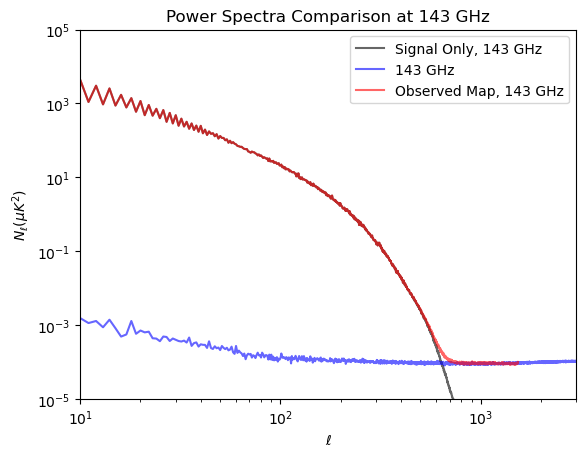

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration ---
PLOT_FREQ = 143 # Focus on the cleanest (CMB-dominated) channel

# Prepare the data lists by retrieving records
ps_list = []
labels = []
colors = []

# 1. Retrieve Signal C_ell (True signal)
r_signal = recs.get(f"signal_{PLOT_FREQ}GHz")
ps_list.append(r_signal.cl)
labels.append(r_signal.label)
colors.append('black') # Clean signal is often black

# 2. Retrieve Noise N_ell (The noise floor)
r_noise = recs.get(f"ffp10_noise_{PLOT_FREQ}GHz")
ps_list.append(r_noise.cl)
labels.append(r_noise.label)
colors.append('blue') # Noise floor

# 3. Retrieve Observed C_ell (Signal + Noise)
r_obs = recs.get(f"obs_{PLOT_FREQ}GHz")
ps_list.append(r_obs.cl)
labels.append(r_obs.label)
colors.append('red') # Observed is often red

# Define Plot Limits (suitable for uK^2 data on a log-log plot)
class Extents:
    def __init__(self, xmin, xmax, ymin, ymax):
        self.xmin, self.xmax = xmin, xmax
        self.ymin, self.ymax = ymin, ymax

plot_extents_ps = Extents(10, 3000, 1e-5, 1e5) 

# --- Plotting Call ---
plot_ps(many_ps_list=ps_list,
        labels=labels, 
        title=f"Power Spectra Comparison at {PLOT_FREQ} GHz",
        colors=colors,
        x_high=plot_extents_ps.xmax,
        x_low=plot_extents_ps.xmin,
        y_high=plot_extents_ps.ymax,
        y_low=plot_extents_ps.ymin,
        loglog=True,
        scatter=False)

/tmp/ipykernel_2269911/4052683109.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


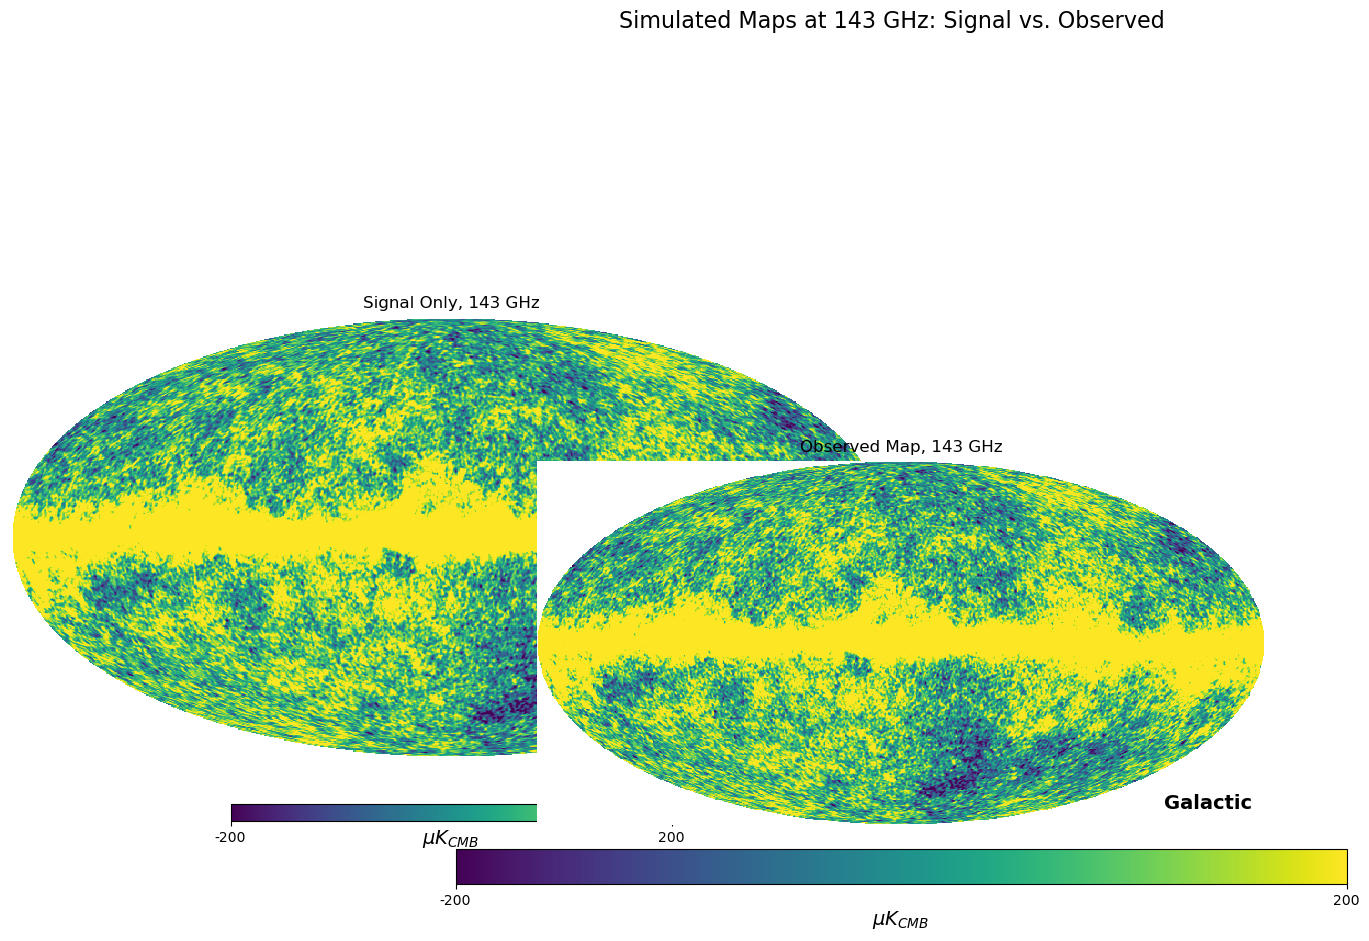

In [ ]:
import healpy as hp

# --- Map Comparison Plot ---
r_signal = recs.get(f"signal_{PLOT_FREQ}GHz")
r_obs = recs.get(f"obs_{PLOT_FREQ}GHz")

fig = plt.figure(figsize=(18, 9))
plt.suptitle(f"Simulated Maps at {PLOT_FREQ} GHz: Signal vs. Observed", fontsize=16) 

# Assuming a consistent min/max for visual comparison of the CMB/foreground
MAP_VMIN, MAP_VMAX = -200, 200 # uK_CMB limits

# Plot 1: Clean Signal Map
hp.mollview(
    r_signal.sky, 
    title=r_signal.label, 
    unit=r"$\mu K_{CMB}$",
    coord=['G'], 
    cmap='viridis',
    sub=(2, 1, 1), # Plot 1 of 2
    cbar=True,
    min=MAP_VMIN,
    max=MAP_VMAX
)

# Plot 2: Observed (Noisy) Map
hp.mollview(
    r_obs.sky, 
    title=r_obs.label, 
    unit=r"$\mu K_{CMB}$",
    coord=['G'], 
    cmap='viridis', 
    sub=(2, 1, 2), # Plot 2 of 2
    cbar=True,
    min=MAP_VMIN,
    max=MAP_VMAX
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()